In [37]:
#1. import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay



In [47]:
#2 genrate larger data set
np.random.seed(42)
random.seed(42)
n_samples=300
data={
    'weather':np.random.choice(['sunny','cloudy','rainy'],n_samples),
    'soil':np.random.choice(['dry','moist','cool'],n_samples),
    'temperature':np.random.choice(['hot','mild','cool'],n_samples),
    'humidity':np.random.choice(['high','medium','low'],n_samples),
    'wind':np.random.choice(['strong','weak'],n_samples),
    'fertilizer':np.random.choice(['yes','no'],n_samples),
    'crop_type':np.random.choice(['wheat','rice','corn'],n_samples),
    'season':np.random.choice(['kharif','rabi','summer'],n_samples)
}
df=pd.DataFrame(data)
print(df)




    weather  soil temperature humidity    wind fertilizer crop_type  season
0     rainy  cool         hot      low    weak         no      corn  summer
1     sunny   dry        cool     high    weak         no      rice  summer
2     rainy   dry         hot   medium  strong         no      corn  summer
3     rainy   dry        cool     high    weak         no      rice    rabi
4     sunny   dry         hot      low  strong         no      rice    rabi
..      ...   ...         ...      ...     ...        ...       ...     ...
295  cloudy   dry        mild   medium  strong        yes      rice  kharif
296  cloudy  cool         hot     high  strong         no      rice    rabi
297  cloudy   dry        mild   medium    weak         no      rice  kharif
298  cloudy  cool        mild      low  strong        yes      corn  kharif
299  cloudy   dry         hot     high    weak        yes      corn    rabi

[300 rows x 8 columns]


In [39]:
#3 target with NOISE
def irrigation_rule(row):
  if row['soil']=='dry' and row['weather']!='rainy':
    base='yes'
  elif row['soil']=='wet':
    base='no'
  else:
    base=random.choice(['yes','no'])
  #add noice (flip label with 20% probaBALILITY)
  if random.random()<0.2:
    return "no" if base == 'yes' else 'yes'
  return base
df['irrigate']=df.apply(irrigation_rule,axis=1)



In [40]:
#4 encode data
le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])


#5 split data
X=df.drop('irrigate',axis=1)
y=df['irrigate']


X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42,stratify=y
    )

#6 DEcision tree (high variance)
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)

y_pred_dt=dt_model.predict(X_test)\

#7 Random Forest (variance reduction )
rf_model=RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=42

)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)




In [41]:
#8 Accuracy comparison
dt_accuracy=accuracy_score(y_test,y_pred_dt)
rf_accuracy=accuracy_score(y_test,y_pred_rf)
print('\nAccuracy comparison:')
print("Decision Tree accuracy :",dt_accuracy)
print("random Forest Accuracy:",rf_accuracy)






Accuracy comparison:
Decision Tree accuracy : 0.5888888888888889
random Forest Accuracy: 0.5111111111111111


In [42]:

#9 confusion matrix
cm_dt=confusion_matrix(y_test,y_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(y_test,y_pred_dt,labels=[0,1])


print("\n Decision Tree Confusion Matrix :\n ", cm_dt)
print("\n Random Forest Confusion Matrix :\n ", cm_rf)


 Decision Tree Confusion Matrix :
  [[18 21]
 [16 35]]

 Random Forest Confusion Matrix :
  [[18 21]
 [16 35]]


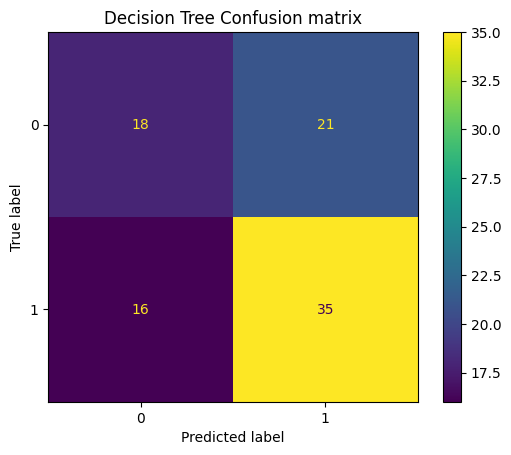

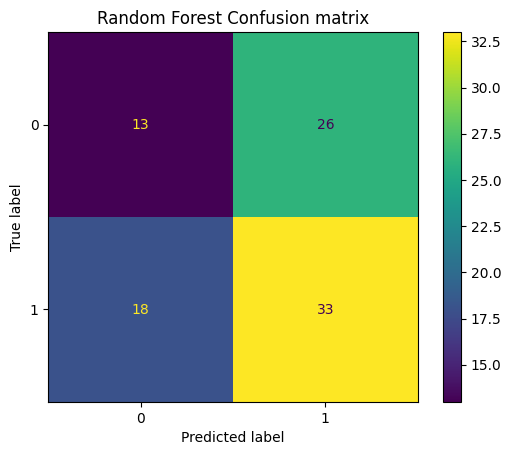

In [43]:
#10 visual confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt,labels=[0,1])
plt.title("Decision Tree Confusion matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_rf,labels=[0,1])
plt.title("Random Forest Confusion matrix")
plt.show()


In [44]:
#11 cross validation dt_cv=cross_val_score(dt_model,X,y,cv=5)
rf_cv=cross_val_score(rf_model,X,y,cv=5)
print("\n Cross validation accuracy:")
print("Decision Tree:",dt_cv.mean())
print("random Forest:",rf_cv.mean())




 Cross validation accuracy:
Decision Tree: 0.5599999999999999
random Forest: 0.5666666666666667
